# 09 Nikolov Models

Small-scale verification and visualization for the Nikolov TO, LE, and MH LP baselines. Use `RUN_TO`, `RUN_LE`, and `RUN_MH` to choose which model sections execute.

In [11]:
from pathlib import Path
import os
import sys
import time

SEED = 20210527
PROFILE_NAME = "BASE" # "SMOKE" or "BASE"

RUN_TO = True
RUN_LE = True
RUN_MH = True

OUTPUT_ROOT = Path("outputs/notebooks/09_nikolov_models")
SAVE_FIGURES = True
FIG_DPI = 160

LP_TOL = 1e-7
POLICY_TOL = 1e-7

PARAM_KWARGS = dict(
    tau=0.20,
    alpha=0.50,
    f=0.0,
    delta=0.10,
    psi=0.08,
    r=0.04,
    kappa=0.50,
    eta_bar=0.005,
    xi=0.50,
    theta=1.0,
    lambda_diversion=0.02,
)

AR1_KWARGS = dict(rho=0.70, sigma=0.08, mu=0.0, z_sd_mult=2.0)
SMOKE_Z_TRANSITION = [[0.8, 0.2], [0.3, 0.7]]

TO_BASE_GRID = dict(n_k=25, n_b=25, n_z=10, k_low_mult=0.30, k_high_mult=2.00, debt_fraction_of_k_ref=2.50)
LE_BASE_GRID = dict(n_k=13, n_b=3, n_p=3, n_z=5, k_low_mult=0.50, k_high_mult=1.50, debt_pledge_fraction=0.35)
MH_BASE_GRID = dict(n_k=13, n_v=3, n_d=3, n_z=5, k_low_mult=0.50, k_high_mult=1.50, v_low_fraction_of_k_ref=0.02, v_high_fraction_of_k_ref=0.20)

MH_SOLVER_KWARGS = dict(ic_tol=1e-3)

if PROFILE_NAME not in {"SMOKE", "BASE"}:
    raise ValueError("PROFILE_NAME must be 'SMOKE' or 'BASE'.")

REPO_ROOT = Path.cwd()
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "src" / "v2").exists():
        REPO_ROOT = candidate
        break
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

PROFILE_OUTPUT_ROOT = (OUTPUT_ROOT if OUTPUT_ROOT.is_absolute() else REPO_ROOT / OUTPUT_ROOT) / PROFILE_NAME
PROFILE_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(PROFILE_OUTPUT_ROOT / ".mplconfig"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

print(f"profile={PROFILE_NAME} seed={SEED}")
print(f"run: TO={RUN_TO} LE={RUN_LE} MH={RUN_MH}")
print(f"eta_bar={PARAM_KWARGS['eta_bar']} lambda_diversion={PARAM_KWARGS['lambda_diversion']} kappa={PARAM_KWARGS['kappa']}")
print(f"output={PROFILE_OUTPUT_ROOT.relative_to(REPO_ROOT)}")
if PROFILE_NAME == "BASE" and RUN_TO:
    print("note: BASE TO uses 25 x 25 x 10 and can be slow with the current pure-Python LP assembly.")

profile=BASE seed=20210527
run: TO=True LE=True MH=True
eta_bar=0.005 lambda_diversion=0.02 kappa=0.5
output=outputs/notebooks/09_nikolov_models/BASE
note: BASE TO uses 25 x 25 x 10 and can be slow with the current pure-Python LP assembly.


In [12]:
import numpy as np
import matplotlib.pyplot as plt

from src.v2.environments.nikolov import (
    NikolovGridConfig,
    NikolovParams,
    ar1_z_bounds,
    build_nikolov_grids,
    calibrated_k_bounds,
    conservative_debt_bound,
    eta_grid,
    reference_capital,
)
from src.v2.solvers.nikolov_to import solve_nikolov_to
from src.v2.solvers.nikolov_le import solve_nikolov_le
from src.v2.solvers.nikolov_mh import solve_nikolov_mh

rng = np.random.default_rng(SEED)
del rng

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

params = NikolovParams(**PARAM_KWARGS)


def _base_scales():
    z_bar = float(np.exp(AR1_KWARGS["mu"]))
    k_ref = reference_capital(params, z_bar=z_bar)
    z_bounds = ar1_z_bounds(**AR1_KWARGS)
    return k_ref, z_bar, z_bounds


def _smoke_config():
    k_ref = reference_capital(params)
    return NikolovGridConfig(
        k_bounds=(1.0, 1.2),
        b_bounds=(0.0, 0.5),
        v_bounds=(0.02 * k_ref, 0.20 * k_ref),
        z_bounds=(1.0, 1.1),
        p_bounds=(0.0, params.r * 0.5),
        d_bounds=(params.r * 0.02 * k_ref, params.r * 0.20 * k_ref),
        n_k=3,
        n_b=2,
        n_v=3,
        n_z=2,
        n_p=2,
        n_d=3,
        z_transition=np.asarray(SMOKE_Z_TRANSITION, dtype=float),
    )


def build_to_config():
    if PROFILE_NAME == "SMOKE":
        return _smoke_config()
    k_ref, z_bar, z_bounds = _base_scales()
    k_bounds = calibrated_k_bounds(params, low_mult=TO_BASE_GRID["k_low_mult"], high_mult=TO_BASE_GRID["k_high_mult"], z_bar=z_bar)
    b_max = TO_BASE_GRID["debt_fraction_of_k_ref"] * k_ref
    return NikolovGridConfig(
        k_bounds=k_bounds,
        b_bounds=(0.0, b_max),
        v_bounds=(0.0, 0.20 * k_ref),
        z_bounds=z_bounds,
        p_bounds=(0.0, params.r * b_max),
        d_bounds=(0.0, params.r * 0.20 * k_ref),
        n_k=TO_BASE_GRID["n_k"],
        n_b=TO_BASE_GRID["n_b"],
        n_v=2,
        n_z=TO_BASE_GRID["n_z"],
        n_p=2,
        n_d=2,
        z_rho=AR1_KWARGS["rho"],
        z_sigma=AR1_KWARGS["sigma"],
        z_mu=AR1_KWARGS["mu"],
    )


def build_le_config():
    if PROFILE_NAME == "SMOKE":
        return _smoke_config()
    k_ref, z_bar, z_bounds = _base_scales()
    k_bounds = calibrated_k_bounds(params, low_mult=LE_BASE_GRID["k_low_mult"], high_mult=LE_BASE_GRID["k_high_mult"], z_bar=z_bar)
    b_max = conservative_debt_bound(params, k_low=k_bounds[0], pledge_fraction=LE_BASE_GRID["debt_pledge_fraction"])
    return NikolovGridConfig(
        k_bounds=k_bounds,
        b_bounds=(0.0, b_max),
        v_bounds=(0.0, 0.20 * k_ref),
        z_bounds=z_bounds,
        p_bounds=(0.0, params.r * b_max),
        d_bounds=(0.0, params.r * 0.20 * k_ref),
        n_k=LE_BASE_GRID["n_k"],
        n_b=LE_BASE_GRID["n_b"],
        n_v=2,
        n_z=LE_BASE_GRID["n_z"],
        n_p=LE_BASE_GRID["n_p"],
        n_d=2,
        z_rho=AR1_KWARGS["rho"],
        z_sigma=AR1_KWARGS["sigma"],
        z_mu=AR1_KWARGS["mu"],
    )


def build_mh_config():
    if PROFILE_NAME == "SMOKE":
        return _smoke_config()
    k_ref, z_bar, z_bounds = _base_scales()
    k_bounds = calibrated_k_bounds(params, low_mult=MH_BASE_GRID["k_low_mult"], high_mult=MH_BASE_GRID["k_high_mult"], z_bar=z_bar)
    b_max = conservative_debt_bound(params, k_low=k_bounds[0], pledge_fraction=0.35)
    v_min = MH_BASE_GRID["v_low_fraction_of_k_ref"] * k_ref
    v_max = MH_BASE_GRID["v_high_fraction_of_k_ref"] * k_ref
    return NikolovGridConfig(
        k_bounds=k_bounds,
        b_bounds=(0.0, b_max),
        v_bounds=(v_min, v_max),
        z_bounds=z_bounds,
        p_bounds=(0.0, params.r * b_max),
        d_bounds=(params.r * v_min, params.r * v_max),
        n_k=MH_BASE_GRID["n_k"],
        n_b=2,
        n_v=MH_BASE_GRID["n_v"],
        n_z=MH_BASE_GRID["n_z"],
        n_p=2,
        n_d=MH_BASE_GRID["n_d"],
        z_rho=AR1_KWARGS["rho"],
        z_sigma=AR1_KWARGS["sigma"],
        z_mu=AR1_KWARGS["mu"],
    )


def print_config(model, config):
    print(f"{model} grid: k={config.n_k}, b={config.n_b}, V={config.n_v}, z={config.n_z}, p={config.n_p}, d={config.n_d}")
    print(f"{model} bounds: k={tuple(round(x, 4) for x in config.k_bounds)}, b={tuple(round(x, 4) for x in config.b_bounds)}, V={tuple(round(x, 4) for x in config.v_bounds)}, z={tuple(round(x, 4) for x in config.z_bounds)}")


def preflight(model, config):
    grids = build_nikolov_grids(config)
    np.testing.assert_allclose(grids["Q"].sum(axis=1), 1.0)
    if model == "LE":
        np.testing.assert_allclose(grids["p"], params.r * grids["b"])
    if model == "MH":
        np.testing.assert_allclose(grids["d"], params.r * grids["v"])
    return grids


def boundary_rate(indices, n):
    idx = np.asarray(indices)
    return float(np.mean((idx == 0) | (idx == n - 1)))


def validate_result(model, result):
    assert result["lp_result"].success, f"{model} LP failed"
    assert np.all(np.isfinite(result["value"])), f"{model} value has non-finite entries"
    assert result["feasible_action_counts"].min() > 0, f"{model} has empty feasible states"
    assert result["diagnostics"]["max_lp_violation"] <= LP_TOL, f"{model} LP violation too large"
    gap = float(np.max(np.abs(result["policy"]["value"] - result["value"])))
    assert gap <= POLICY_TOL, f"{model} policy/value gap too large: {gap}"
    if model == "TO":
        np.testing.assert_allclose(result["premium_grid"][:, 0, :], 0.0)
        np.testing.assert_allclose(result["default_probability_grid"][:, 0, :], 0.0)
    return gap


def print_result(model, result, wall_time, policy_gap):
    grids = result["grids"]
    kbr = boundary_rate(result["policy"]["k_next_idx"], len(grids["k"]))
    print(f"{model} done in {wall_time:.2f}s")
    print(f"{model} value shape={result['value'].shape}, min={result['value'].min():.4f}, max={result['value'].max():.4f}")
    print(f"{model} feasible actions: min={result['feasible_action_counts'].min()}, max={result['feasible_action_counts'].max()}")
    print(f"{model} max LP violation={result['diagnostics']['max_lp_violation']:.2e}, policy gap={policy_gap:.2e}, k-boundary rate={kbr:.1%}")


def save_figure(fig, filename):
    path = PROFILE_OUTPUT_ROOT / filename
    if SAVE_FIGURES:
        fig.savefig(path, dpi=FIG_DPI, bbox_inches="tight")
        print(f"saved {path.relative_to(REPO_ROOT)}")
    return path


def z_label(z_grid, iz):
    return f"z={z_grid[iz]:.3g}"


def expected_contract_slice(arr, result, fin_idx, z_idx):
    eta_values, eta_probs = eta_grid(params)
    weights = result["prob_matrix"][z_idx, :, None] * eta_probs[None, :]
    return np.tensordot(arr[:, fin_idx, z_idx, :, :], weights, axes=([1, 2], [0, 1]))

## Trade-Off Model

In [3]:
to_result = None
if RUN_TO:
    to_config = build_to_config()
    print_config("TO", to_config)
    preflight("TO", to_config)
    start = time.perf_counter()
    to_result = solve_nikolov_to(to_config, params)
    wall_time = time.perf_counter() - start
    policy_gap = validate_result("TO", to_result)
    print_result("TO", to_result, wall_time, policy_gap)
else:
    print("TO skipped")

TO grid: k=25, b=25, V=2, z=10, p=2, d=2
TO bounds: k=(3.3333, 22.2222), b=(0.0, 27.7778), V=(0.0, 2.2222), z=(0.7993, 1.2511)
TO done in 610.46s
TO value shape=(25, 25, 10), min=-0.9977, max=56.1965
TO feasible actions: min=429, max=625
TO max LP violation=1.67e-14, policy gap=2.84e-14, k-boundary rate=32.1%


saved outputs/notebooks/09_nikolov_models/BASE/nikolov_to_slices.png


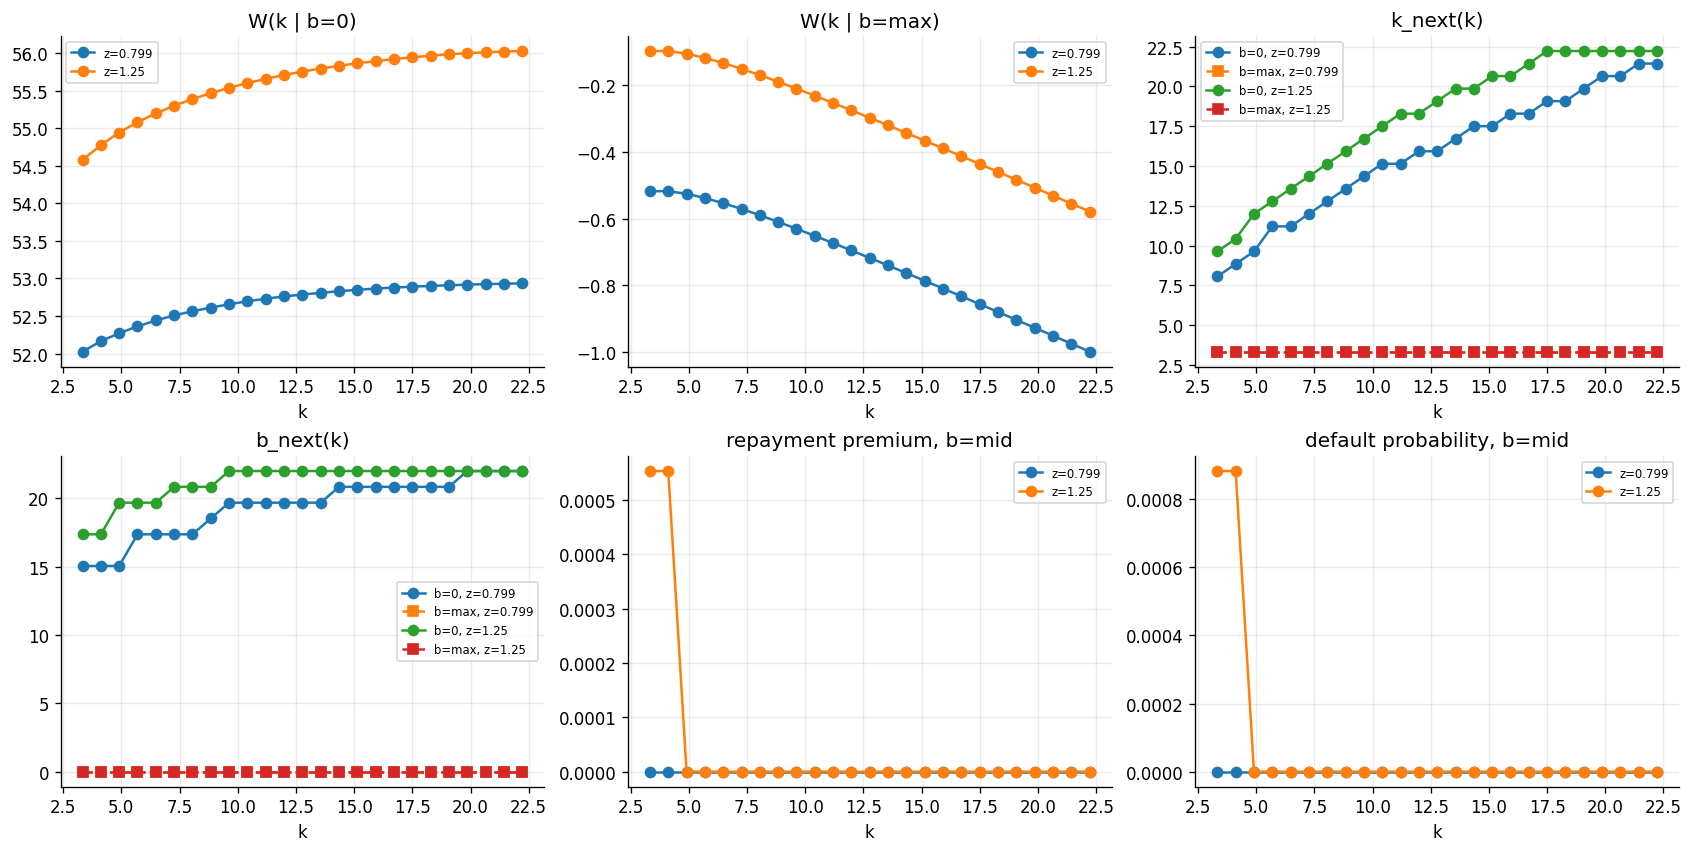

In [10]:
def plot_to(result):
    k = result["grids"]["k"]
    b = result["grids"]["b"]
    z = result["grids"]["z"]
    policy = result["policy"]
    z_indices = [0, len(z) - 1]
    b_low = 0
    b_mid = len(b) // 2
    b_high = len(b) - 1

    fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
    axes = axes.ravel()
    for iz in z_indices:
        axes[0].plot(k, result["value"][:, b_low, iz], marker="o", label=z_label(z, iz))
        axes[1].plot(k, result["value"][:, b_high, iz], marker="o", label=z_label(z, iz))
        axes[2].plot(k, policy["k_next"][:, b_low, iz], marker="o", label=f"b=0, {z_label(z, iz)}")
        axes[2].plot(k, policy["k_next"][:, b_high, iz], marker="s", linestyle="--", label=f"b=max, {z_label(z, iz)}")
        axes[3].plot(k, policy["b_next"][:, b_low, iz], marker="o", label=f"b=0, {z_label(z, iz)}")
        axes[3].plot(k, policy["b_next"][:, b_high, iz], marker="s", linestyle="--", label=f"b=max, {z_label(z, iz)}")
        k_next_idx = policy["k_next_idx"][:, b_mid, iz]
        axes[4].plot(k, policy["repayment_premium"][:, b_mid, iz], marker="o", label=z_label(z, iz))
        axes[5].plot(k, result["default_probability_grid"][k_next_idx, b_mid, iz], marker="o", label=z_label(z, iz))

    titles = ["W(k | b=0)", "W(k | b=max)", "k_next(k)", "b_next(k)", "repayment premium, b=mid", "default probability, b=mid"]
    for ax, title in zip(axes, titles):
        ax.set_title(title)
        ax.set_xlabel("k")
        ax.legend(fontsize=7)
    return fig

if to_result is not None:
    fig = plot_to(to_result)
    save_figure(fig, "nikolov_to_slices.png")
    plt.show()

## Limited-Enforcement Model

In [ ]:
le_result = None
if RUN_LE:
    le_config = build_le_config()
    print_config("LE", le_config)
    preflight("LE", le_config)
    start = time.perf_counter()
    le_result = solve_nikolov_le(le_config, params)
    wall_time = time.perf_counter() - start
    policy_gap = validate_result("LE", le_result)
    print_result("LE", le_result, wall_time, policy_gap)
else:
    print("LE skipped")

LE grid: k=13, b=3, V=2, z=5, p=3, d=2
LE bounds: k=(5.5556, 16.6667), b=(0.0, 1.6827), V=(0.0, 2.2222), z=(0.7993, 1.2511)


In [ ]:
def plot_le(result):
    k = result["grids"]["k"]
    b = result["grids"]["b"]
    z = result["grids"]["z"]
    policy = result["policy"]
    z_indices = [0, len(z) - 1]
    b_low = 0
    b_high = len(b) - 1

    fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
    axes = axes.ravel()
    for iz in z_indices:
        axes[0].plot(k, result["value"][:, b_low, iz], marker="o", label=z_label(z, iz))
        axes[1].plot(k, result["value"][:, b_high, iz], marker="o", label=z_label(z, iz))
        axes[2].plot(k, policy["k_next"][:, b_low, iz], marker="o", label=f"b=0, {z_label(z, iz)}")
        axes[2].plot(k, policy["k_next"][:, b_high, iz], marker="s", linestyle="--", label=f"b=max, {z_label(z, iz)}")
        axes[3].plot(k, expected_contract_slice(policy["b_next"], result, b_high, iz), marker="o", label=z_label(z, iz))
        axes[4].plot(k, expected_contract_slice(policy["p"], result, b_high, iz), marker="o", label=z_label(z, iz))
        axes[5].plot(k, result["feasible_action_counts"][:, b_low, iz], marker="o", label=f"b=0, {z_label(z, iz)}")
        axes[5].plot(k, result["feasible_action_counts"][:, b_high, iz], marker="s", linestyle="--", label=f"b=max, {z_label(z, iz)}")

    titles = ["W(k | b=0)", "W(k | b=max)", "k_next(k)", "E[b_next | b=max]", "E[p | b=max]", "feasible action count"]
    for ax, title in zip(axes, titles):
        ax.set_title(title)
        ax.set_xlabel("k")
        ax.legend(fontsize=7)
    return fig

if le_result is not None:
    fig = plot_le(le_result)
    save_figure(fig, "nikolov_le_slices.png")
    plt.show()

## Moral-Hazard Model

In [ ]:
mh_result = None
if RUN_MH:
    mh_config = build_mh_config()
    print_config("MH", mh_config)
    preflight("MH", mh_config)
    print(f"MH solver kwargs: {MH_SOLVER_KWARGS}")
    start = time.perf_counter()
    mh_result = solve_nikolov_mh(mh_config, params, **MH_SOLVER_KWARGS)
    wall_time = time.perf_counter() - start
    policy_gap = validate_result("MH", mh_result)
    print_result("MH", mh_result, wall_time, policy_gap)
else:
    print("MH skipped")

MH skipped


In [ ]:
def plot_mh(result):
    k = result["grids"]["k"]
    v = result["grids"]["v"]
    z = result["grids"]["z"]
    policy = result["policy"]
    z_indices = [0, len(z) - 1]
    v_low = 0
    v_high = len(v) - 1
    low_label = "V=0" if np.isclose(v[v_low], 0.0) else "V=min"

    fig, axes = plt.subplots(2, 3, figsize=(14, 7), constrained_layout=True)
    axes = axes.ravel()
    for iz in z_indices:
        axes[0].plot(k, result["value"][:, v_low, iz], marker="o", label=z_label(z, iz))
        axes[1].plot(k, result["value"][:, v_high, iz], marker="o", label=z_label(z, iz))
        axes[2].plot(k, policy["k_next"][:, v_low, iz], marker="o", label=f"{low_label}, {z_label(z, iz)}")
        axes[2].plot(k, policy["k_next"][:, v_high, iz], marker="s", linestyle="--", label=f"V=max, {z_label(z, iz)}")
        axes[3].plot(k, expected_contract_slice(policy["V_next"], result, v_high, iz), marker="o", label=z_label(z, iz))
        axes[4].plot(k, expected_contract_slice(policy["d"], result, v_high, iz), marker="o", label=z_label(z, iz))
        axes[5].plot(k, expected_contract_slice(policy["p"], result, v_high, iz), marker="o", label=z_label(z, iz))

    titles = [f"W(k | {low_label})", "W(k | V=max)", "k_next(k)", "E[V_next | V=max]", "E[d | V=max]", "E[p | V=max]"]
    for ax, title in zip(axes, titles):
        ax.set_title(title)
        ax.set_xlabel("k")
        ax.legend(fontsize=7)
    return fig

if mh_result is not None:
    fig = plot_mh(mh_result)
    save_figure(fig, "nikolov_mh_slices.png")
    plt.show()

## Notes

`SMOKE` is for fast pipeline checks. `BASE` turns on private shocks and diversion and uses model-specific grids: TO is intentionally dense, while LE and MH stay conservative because exhaustive contract enumeration grows very quickly. MH uses a small IC tolerance in `MH_SOLVER_KWARGS`; without that tolerance, the finite contract grid usually cannot satisfy positive-shock IC constraints exactly.